# 3. Exploratory Data Analysis (EDA)

With both datasets cleaned, standardized, and prepared for analysis, we now begin the Exploratory Data Analysis (EDA) phase.  
The goal of EDA is to build a comprehensive understanding of:

- The structure and behavior of each dataset  
- The distribution of key numeric and categorical variables  
- Patterns, trends, and anomalies  
- Relationships between borrower characteristics and loan outcomes  
- Early‑stage borrower behavior (inquiries)  
- Insights that guide feature engineering and modeling decisions  

To maintain clarity and consistency, EDA is divided into two major parts:

- **3A  EDA for the Modeling Dataset (`apps_clean`)**  
- **3B  EDA for the Business Insights Dataset (`inq_clean`)**

This mirrors the structure used in Section 2 and ensures that modeling‑related analysis is kept separate from business‑focused insights.

---

# 3A. EDA  Modeling Dataset (`apps_clean`)

The modeling dataset contains all variables available at application time, cleaned and free of leakage.  
We begin with 10 structured EDA questions:

- **5 statistical questions**  
- **5 business questions (always including the target)**  

---

# **3A.1 Statistical EDA Questions (1–5)**

---

## **3A.Q1  What is the distribution of loan amounts?**

In [4]:
import pandas as pd 
import numpy as np

apps_eda = pd.read_csv('../data/apps_eda.csv')
apps_eda.head()

,requested_amount_usd,repayment_term,monthly_installment_usd,risk_grade_detail,employment_tenure,housing_status,annual_income_usd,income_verification_status,origination_month,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,interest_rate,revolving_utilization,target_default
0,18000.0,60 months,412.61,C3,3 years,own,105000.0,verified,2015-02-01,debt_consolidation,az,6.78,670.0,674.0,7.0,0.0,13.33,89.5,0
1,1000.0,36 months,33.21,C1,1 year,rent,28500.0,not verified,2016-04-01,home_improvement,fl,11.54,690.0,694.0,3.0,1.0,11.99,13.3,0
2,21275.0,36 months,696.42,B4,5 years,mortgage,130000.0,verified,2015-09-01,debt_consolidation,pa,23.08,680.0,684.0,13.0,0.0,10.99,75.7,0
3,35000.0,60 months,869.66,D3,10+ years,mortgage,107000.0,verified,2015-09-01,credit_card,sc,16.30,710.0,714.0,10.0,0.0,16.99,76.5,0
4,17000.0,60 months,427.73,D4,8 years,rent,55000.0,verified,2015-04-01,credit_card,ca,31.27,680.0,684.0,8.0,0.0,17.57,62.5,1


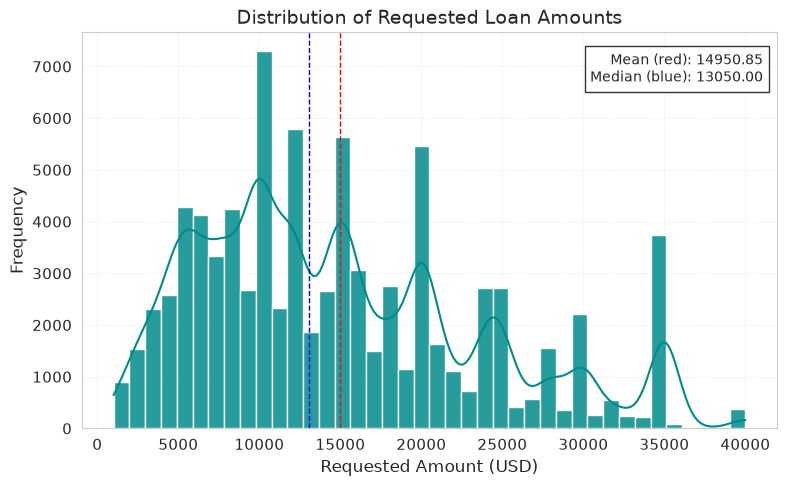

In [8]:
# EDA Setup Cell — Run Once at the Start of Section 3
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

# Calculate mean and median
mean_val = apps_eda['requested_amount_usd'].mean()
median_val = apps_eda['requested_amount_usd'].median()

plt.figure(figsize=(8,5))

# Histogram with a more interesting color (darkcyan)
sns.histplot(
    apps_eda['requested_amount_usd'],
    kde=True,
    bins=40,
    color='darkcyan',
    edgecolor='white',
    alpha=0.85
)

# Softer, lighter gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.35)

# Vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1)
plt.axvline(median_val, color='blue', linestyle='--', linewidth=1)

# Annotation box inside the plot
plt.text(
    0.98, 0.95,
    f"Mean (red): {mean_val:.2f}\nMedian (blue): {median_val:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

# Titles and labels
plt.title("Distribution of Requested Loan Amounts")
plt.xlabel("Requested Amount (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Insight: Distribution of Requested Loan Amounts

The distribution of requested loan amounts shows a clear right‑skewed pattern, indicating that most applicants request moderate loan sizes while a smaller group pushes the upper range with significantly larger requests. This is reflected in the noticeable gap between the **median (~$13,050)** and the **mean (~$14,950)**, where the mean is pulled upward by high‑value outliers.

From a business perspective, this pattern highlights two important dynamics:

- The core of the portfolio is driven by **mid‑sized loan requests**, which likely correspond to common financial needs such as debt consolidation or personal expenses.
- A smaller segment of applicants requests **substantially higher loan amounts**, which can introduce elevated credit risk and may require stricter underwriting or additional verification.

Overall, the loan portfolio is anchored by typical borrowers requesting moderate amounts, but the presence of high‑value outliers introduces meaningful risk considerations that lenders should monitor closely.
